# Stage 1: Data Exploration

**Goal:** Load the Archelec manifesto texts, understand their structure, and produce descriptive statistics.

## 0. Setup

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter

# Project root
PROJECT_ROOT = Path("..")
TEXT_ROOT    = PROJECT_ROOT / "data" / "archelec_repo" / "text_files"

ELECTION_YEARS = ["1973", "1978", "1981", "1988", "1993"]

print("Text root exists:", TEXT_ROOT.exists())

Text root exists: True




Each `.txt` file is **one complete manifesto for one candidate**.  

The filename IS the candidate ID and matches the `id` field in the metadata.  

In [2]:
records = []

for year in ELECTION_YEARS:
    folder = TEXT_ROOT / year / "legislatives"
    if not folder.exists():
        print(f"Missing: {folder}")
        continue
    for fpath in sorted(folder.glob("*.txt")):
        try:
            text = fpath.read_text(encoding="utf-8", errors="replace")
        except Exception:
            text = ""
        records.append({
            "year":         year,
            "candidate_id": fpath.stem,   # full filename without .txt = matches metadata 'id'
            "text":         text,
            "n_words":      len(text.split()),
        })

df_manifestos = pd.DataFrame(records)
print(f"Total manifestos: {len(df_manifestos):,}")
print(f"\nManifestos per year:")
print(df_manifestos.groupby("year").size())
df_manifestos.head(3)

Total manifestos: 21,697

Manifestos per year:
year
1973    3921
1978    5030
1981    3182
1988    3628
1993    5936
dtype: int64


,year,candidate_id,text,n_words
0,1973,EL065_L_1973_03_001_01_1_PF_01,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,492
1,1973,EL065_L_1973_03_001_01_1_PF_02,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,828
2,1973,EL065_L_1973_03_001_01_1_PF_03,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,390




We join on `candidate_id` (from filename) = `id` (from metadata) to attach gender, party, profession and department info. We then keep only candidates with known gender and save the result for reuse in subsequent notebooks.

In [3]:
METADATA_PATH = PROJECT_ROOT / "data" / "archelec_metadata_full.csv"
df_meta = pd.read_csv(METADATA_PATH, sep=",", encoding="utf-8", low_memory=False)
print(f"Total manifestos with metadata: {len(df_meta):,}")
df_meta.head(3)

Total manifestos with metadata: 33,031


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non


In [4]:
df_meta_leg = df_meta[df_meta["subject"].str.contains("législatives", na=False)].copy()
df_meta_leg["year"] = pd.to_datetime(df_meta_leg["date"]).dt.year.astype(str)
df_meta_leg = df_meta_leg[df_meta_leg["year"].isin(ELECTION_YEARS)]

df = df_manifestos.merge(
    df_meta_leg[[
        "id", "titulaire-sexe", "titulaire-soutien",
        "titulaire-nom", "titulaire-prenom",
        "titulaire-profession", "departement-nom", "year"
    ]],
    left_on="candidate_id", right_on="id", how="left"
)

print(f"Manifestos with metadata match: {df['titulaire-sexe'].notna().sum():,} / {len(df):,}")
print(f"\nGender distribution in our corpus:")
print(df["titulaire-sexe"].value_counts())
print(f"\n% female in corpus: {(df['titulaire-sexe'] == 'femme').mean()*100:.1f}%")

# Keep only candidates with known gender
df = df[df["titulaire-sexe"].isin(["homme", "femme"])].reset_index(drop=True)
print(f"\nAfter filtering to known gender: {len(df):,}")

out_path = PROJECT_ROOT / "data" / "manifestos_with_metadata.csv"
df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

Manifestos with metadata match: 21,167 / 21,697

Gender distribution in our corpus:
titulaire-sexe
homme            18171
femme             2160
non déterminé      836
Name: count, dtype: int64

% female in corpus: 10.0%

After filtering to known gender: 20,331
Saved to ../data/manifestos_with_metadata.csv


## 1. Evolution of Female Candidates Over Time

According to the metadata, the share of female candidates evolved unevenly across all legislative elections from 1958 to 1993. Starting from very low levels in 1958, female candidacies grew, peaking at 13.6% in 1978, then declining sharply before recovering 
to around 11% by 1993. 

The stars mark the 5 election years for which digitized manifesto text is available, which is our study window. 

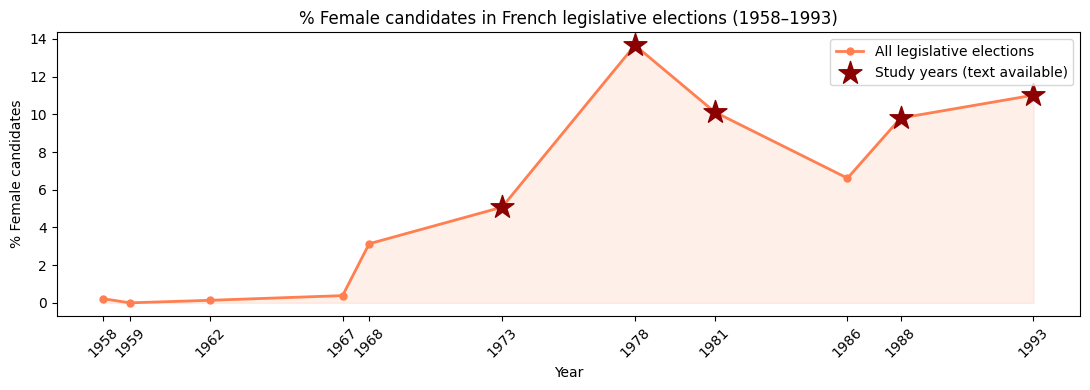

 year  pct_female
 1958    0.216294
 1959    0.000000
 1962    0.134168
 1967    0.383142
 1968    3.133705
 1973    5.074161
 1978   13.664596
 1981   10.124960
 1986    6.611570
 1988    9.802260
 1993   11.015933


In [5]:
# Use full metadata (all legislative elections, not just our 5 years)
df_all_leg = df_meta[df_meta["subject"].str.contains("législatives", na=False)].copy()
df_all_leg["year"] = pd.to_datetime(df_all_leg["date"]).dt.year

pct_female = (
    df_all_leg.groupby("year")["titulaire-sexe"]
    .apply(lambda x: (x == "femme").sum() / len(x) * 100)
    .reset_index(name="pct_female")
)

study_years = [1973, 1978, 1981, 1988, 1993]
study_points = pct_female[pct_female["year"].isin(study_years)]

plt.figure(figsize=(11, 4))
plt.plot(pct_female["year"], pct_female["pct_female"],
         marker="o", color="coral", linewidth=2, markersize=5, label="All legislative elections")
plt.fill_between(pct_female["year"], pct_female["pct_female"], alpha=0.12, color="coral")

# Highlight study years with stars
plt.scatter(study_points["year"], study_points["pct_female"],
            marker="*", s=300, color="darkred", zorder=5, label="Study years (text available)")

plt.title("% Female candidates in French legislative elections (1958–1993)", fontsize=12)
plt.xlabel("Year")
plt.ylabel("% Female candidates")
plt.xticks(pct_female["year"], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fig_female_evolution.png", dpi=150)
plt.show()

print(pct_female.to_string(index=False))

## 2. Descriptive Statistics

Number of manifestos per election year and distribution of manifesto length, broken down by gender. Female candidates write slightly longer manifestos on average (median 761 words vs 627 for men).

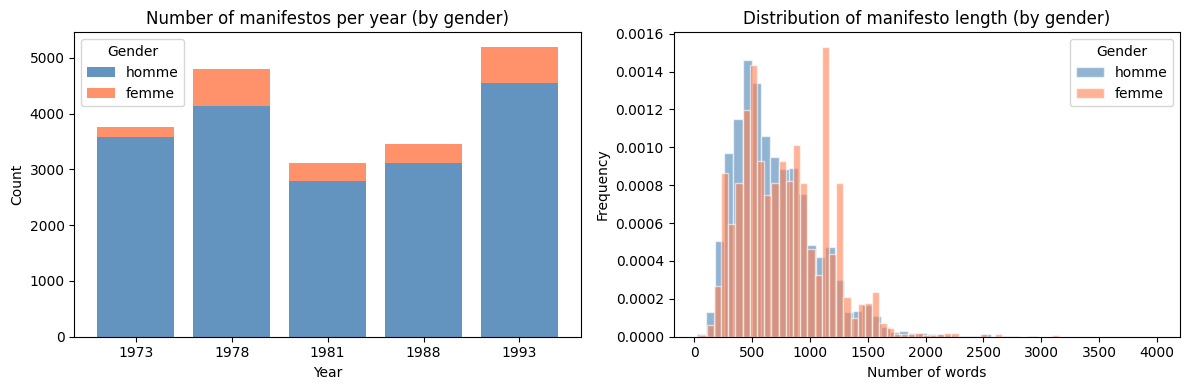


Word count summary by gender:
                  count   mean    std   min    25%    50%     75%     max
titulaire-sexe                                                           
femme            2160.0  789.0  380.0  43.0  488.0  761.0  1076.0  3158.0
homme           18171.0  701.0  358.0  19.0  440.0  627.0   900.0  4002.0


In [6]:
GENDER_COLORS = {"homme": "steelblue", "femme": "coral"}

df_with_gender = df[df["titulaire-sexe"].isin(["homme", "femme"])].copy()
df_with_gender["n_words"] = df_with_gender["text"].apply(lambda t: len(t.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: stacked bar — manifestos per year by gender ---
counts_gender = (
    df_with_gender.groupby(["year_x", "titulaire-sexe"])
    .size()
    .unstack(fill_value=0)
)
bottom = None
for gender, color in GENDER_COLORS.items():
    if gender not in counts_gender.columns:
        continue
    axes[0].bar(counts_gender.index, counts_gender[gender],
                bottom=bottom, color=color, label=gender, alpha=0.85)
    bottom = counts_gender[gender] if bottom is None else bottom + counts_gender[gender]
axes[0].set_title("Number of manifestos per year (by gender)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].legend(title="Gender")

# --- Right: density histogram — normalized so male/female are comparable 
for gender, color in GENDER_COLORS.items():
    subset = df_with_gender[df_with_gender["titulaire-sexe"] == gender]["n_words"]
    axes[1].hist(subset, bins=50, color=color, alpha=0.6, edgecolor="white", label=gender, density=True)
axes[1].set_title("Distribution of manifesto length (by gender)")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Frequency")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fig_descriptive.png", dpi=150)
plt.show()

print("\nWord count summary by gender:")
print(df_with_gender.groupby("titulaire-sexe")["n_words"].describe().round(0))

## 3. Exploring a manifesto
A random example to inspect text quality and OCR output.

In [7]:
sample = df_manifestos.sample(1, random_state=42).iloc[0]
print(f"Year: {sample.year} | Words: {sample.n_words}")
print("-" * 60)
print(sample.text[:800])

Year: 1973 | Words: 1023
------------------------------------------------------------
4ème Circonscription SELESTAT-ERSTEIN
ELECTIONS LEGISLATIVES 1973
une majorité pour la France
Mit DE GAULLE gestern Mit G. POMPIDOU, heute und morgen
Werte Wählerinnen und Wähler !
Ein herzlicher und aufrichtiger Dank
all denjenigen die mir, so zahlreich, am letzten Sonntag, einmal mehr Ihr Vertrauen ausge- sprochen haben.
Mehr als 24.000
Wählerinnen und Wähler haben mir erneut Ihr Vertrauen geschenkt und verlangen somit die Fortsetzung einer Politik des sozialen Fortschritts und das Verfolgen eines einzigen und gleichen Zieles :
- Freiheit und Demokratie sollen garantiert sein,
- Die Entwicklung unseres Landes in einem europäischen und liberalen Rahmen muss gesichert sein, damit Jeder besser leben kann,
- Die Regionalisation muss tiefgreifender werden, sowie es von General De GAULLE verla


### 3.1 Language Detection

Some manifestos may not be written in French (e.g. German in Alsace-Moselle). Since subsequent notebooks use CamemBERT-NER trained on French, we quantify the extent of this limitation here.

In [8]:
from langdetect import detect, LangDetectException                                            
                                                                                                
def detect_lang(text):                                                                        
      try:                                                                                      
          return detect(text[:500])                                 
      except LangDetectException:                                                               
          return "unknown"                    
                                                                                                
df_manifestos["lang"] = df_manifestos["text"].apply(detect_lang)
print(df_manifestos["lang"].value_counts().head(15))

lang
fr    21226
en      416
de       34
ca       13
pt        3
id        2
nl        1
sw        1
et        1
Name: count, dtype: int64


### 3.2 OCR Quality

We measure OCR noise as the ratio of non-alphabetic, non-space characters per manifesto. Lower score = cleaner text.

In [11]:
def ocr_noise_score(text):
    if len(text) == 0:
        return 0
    noise = sum(1 for c in text if not c.isalpha() and not c.isspace())
    return noise / len(text)

df_manifestos["ocr_noise"] = df_manifestos["text"].apply(ocr_noise_score)

print("OCR noise score by year (lower = cleaner):")
print(df_manifestos.groupby("year")["ocr_noise"].mean().round(3))

OCR noise score by year (lower = cleaner):
year
1973    0.045
1978    0.045
1981    0.044
1988    0.045
1993    0.044
Name: ocr_noise, dtype: float64


## 4. Digitization Coverage by Gender

Is the digitization coverage equal across genders? If male candidates are more likely to have a surviving text file, our corpus would be doubly biased. As shown below, coverage is virtually identical across genders (~100%).

=== Digitization coverage by gender ===
titulaire-sexe  with_text  total  coverage_%
         femme       2160   2161       100.0
         homme      18171  18174       100.0


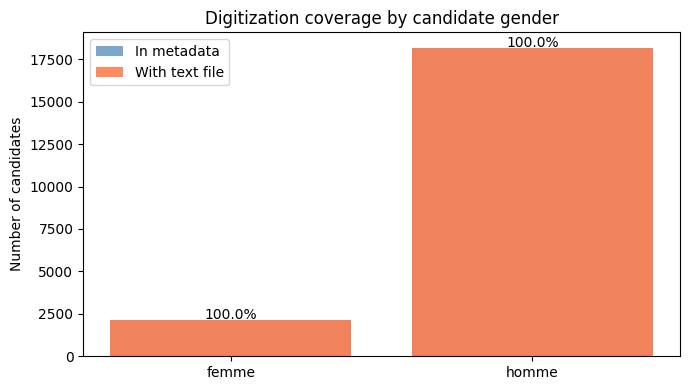

In [12]:
# Coverage by gender using the joined dataframe
coverage_by_gender = (
    df.groupby("titulaire-sexe")["candidate_id"]
    .count()
    .rename("with_text")
    .reset_index()
)

# Total per gender in metadata
total_by_gender = (
    df_meta_leg.groupby("titulaire-sexe")["id"]
    .count()
    .rename("total")
    .reset_index()
)

gender_cov = coverage_by_gender.merge(total_by_gender, on="titulaire-sexe")
gender_cov["coverage_%"] = (gender_cov["with_text"] / gender_cov["total"] * 100).round(1)

print("=== Digitization coverage by gender ===")
print(gender_cov.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(gender_cov))
ax.bar(x, gender_cov["total"], label="In metadata", color="steelblue", alpha=0.7)
ax.bar(x, gender_cov["with_text"], label="With text file", color="coral", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(gender_cov["titulaire-sexe"])
ax.set_title("Digitization coverage by candidate gender")
ax.set_ylabel("Number of candidates")
ax.legend()
for i, row in gender_cov.iterrows():
    ax.text(i, row["with_text"] + 30, f"{row['coverage_%']}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fig_coverage_by_gender.png", dpi=150)
plt.show()